In [122]:
# Import Libraries
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize']= (12,8)

# Reading the data
df = pd.read_csv(r"C:\Users\hugo9\python course\movies.csv")

In [159]:
# Looking at the data
# df.head()

In [124]:
# Checking for missing data percentages
for column in df.columns:
    percent_missing = np.mean(df[column].isnull())
    print('{} - {}%'.format(column,percent_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [125]:
df[df['budget'].isnull() | df['gross'].isnull()] # check for movies which miss monetary information
for x in df.index: # dropping movies that doesn't have budget or gross information
    if pd.isna(df.loc[x, 'budget']) or pd.isna(df.loc[x, 'gross']):
        df.drop(x, inplace = True)

In [126]:
df[df.isnull().any(axis=1)] # checking for missing values no related to money
df = df.fillna('') # filling NaN with blanks

In [160]:
# data types for our columns
# df.dtypes

In [161]:
# changing data type of budget and gross columns to get rid of the decimals of the value
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
# df

In [162]:
# creating a correct year of release column
df['yearcorrect'] = df['released'].astype(str).str.extract(r',\s*(\d{4})') # extracting the year of release using regex
# df

In [130]:
# ordering by the gross revenue
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [131]:
pd.set_option('display.max_rows', 20)

In [163]:
# removing any duplicates
# df.drop_duplicates()

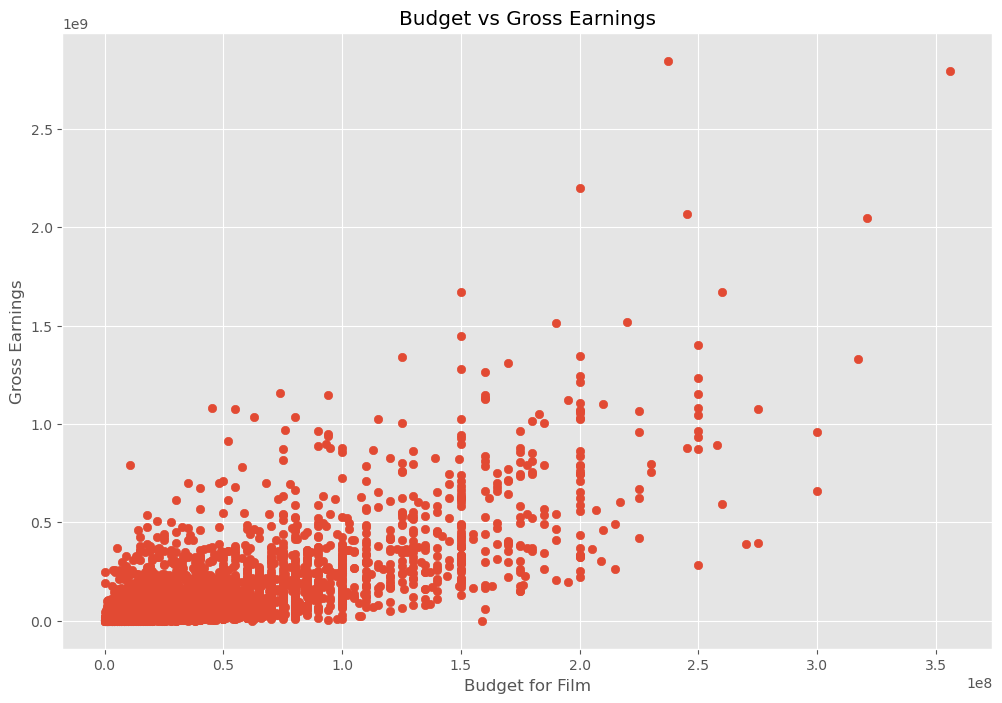

In [133]:
# scatter plot (budget vs gross revenue)
plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Budget for Film')
plt.ylabel('Gross Earnings')
plt.show()

In [164]:
#df.head()

In [135]:
# plot budget vs gross using seaborn
sns.regplot(x='budget', y='gross', data = df, scatter_kws={'color': 'red'}, line_kws={'color':'blue'})

<Axes: xlabel='budget', ylabel='gross'>

In [136]:
# looking at correlation
df.corr(numeric_only=True, method='pearson')

,year,score,votes,budget,gross
year,1.000000,0.055174,0.205758,0.327781,0.274264
score,0.055174,1.000000,0.473809,0.071792,0.222143
votes,0.205758,0.473809,1.000000,0.440021,0.614904
budget,0.327781,0.071792,0.440021,1.000000,0.740395
gross,0.274264,0.222143,0.614904,0.740395,1.000000


In [137]:
correlation_matrix = df.corr(numeric_only=True)

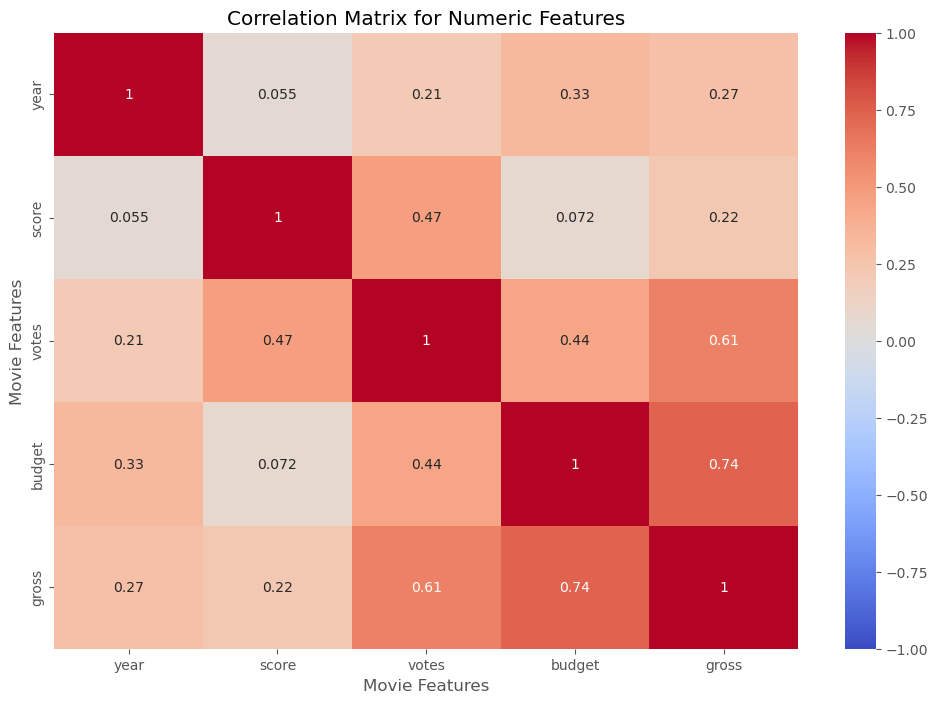

In [138]:
sns.heatmap(correlation_matrix, annot = True, vmin=-1, vmax=1, cmap="coolwarm")
plt.title('Correlation Matrix for Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [165]:
# Looking at qualitative variables
df_discrete = df.copy()

# Turning all qualitative into quantitative
for col_name in df_discrete.columns:
    if(df_discrete[col_name].dtype == 'object'):
        df_discrete[col_name] = df_discrete[col_name].astype('category')
        df_discrete[col_name] = df_discrete[col_name].cat.codes

#df_discrete

In [166]:
# df

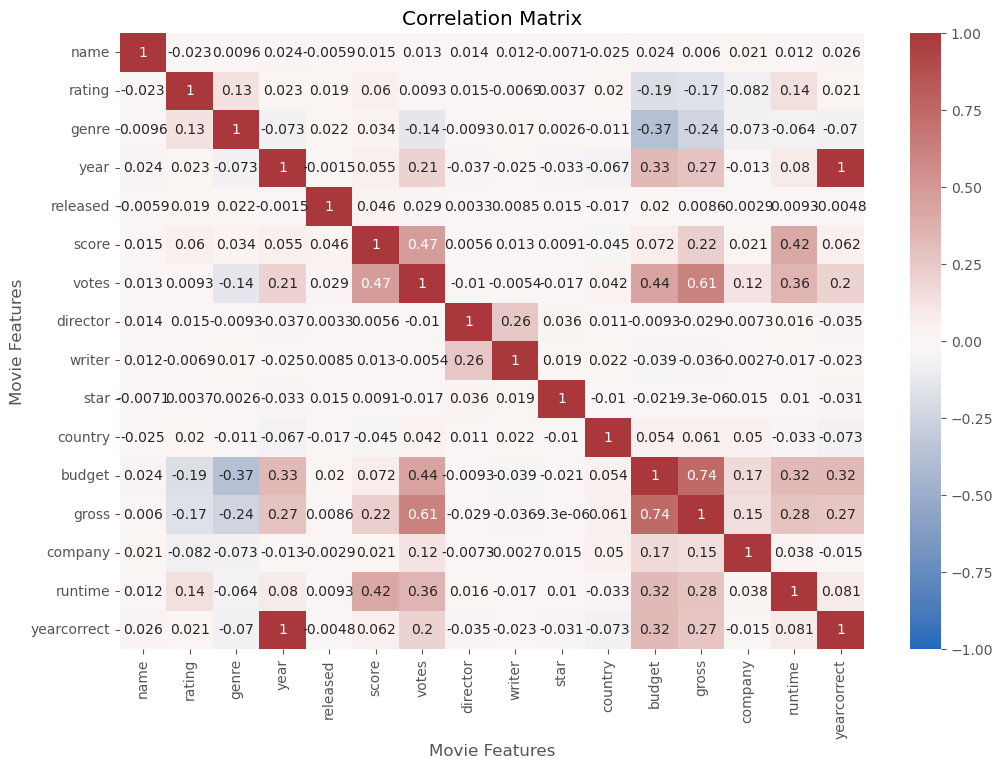

In [145]:
correlation_matrix_discrete = df_discrete.corr(numeric_only=True)
sns.heatmap(correlation_matrix_discrete, annot = True, vmin=-1, vmax=1, cmap="vlag")
plt.title('Correlation Matrix')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

In [147]:
corr_pair = correlation_matrix_discrete.unstack()
sorted_corr_pairs = corr_pair.sort_values()

In [153]:
high_corr = sorted_corr_pairs[(sorted_corr_pairs) >0.5]

In [157]:
high_corr

gross        votes          0.614904
votes        gross          0.614904
gross        budget         0.740395
budget       gross          0.740395
year         yearcorrect    0.996642
yearcorrect  year           0.996642
director     director       1.000000
votes        votes          1.000000
released     released       1.000000
score        score          1.000000
rating       rating         1.000000
name         name           1.000000
genre        genre          1.000000
year         year           1.000000
budget       budget         1.000000
country      country        1.000000
writer       writer         1.000000
star         star           1.000000
company      company        1.000000
gross        gross          1.000000
runtime      runtime        1.000000
yearcorrect  yearcorrect    1.000000
dtype: float64

In [158]:
# Budget and votes have the highest correlation to gross earnings